# K-Means

- Images 32x32 RGB, six formes (`bar`, `circle`, `cross`, `square`, `star`, `triangle`) sur fond sombre bruité ; couleur, taille, position et rotation tirées aléatoirement.

- Fil conducteur expérimental : faire varier K et le nombre d'initialisations, mesurer l'effet sur chaque angle.

In [2]:
import sys
from pathlib import Path

# src/ importable et racine du projet comme dossier courant
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import os
os.chdir(ROOT)

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.kmeans import KMeans
from src.metrics import compression_report, Latent
from src.dataset import load_shapes_dataset
from src.helper import extract_full_dataset

rng = np.random.default_rng(0)
%matplotlib inline

## 1. Chargement et préparation des données

- Sous-ensemble de N = 10 000 images : suffisant pour l'étude, assez léger pour ré-exécuter vite.
- Chaque image `(3, 32, 32)` aplatie à la volée en 3072 composantes ; `ToTensor` a déjà ramené les pixels dans `[0, 1]`, distance euclidienne homogène.

In [3]:
torch.manual_seed(0)
dataloader = load_shapes_dataset(data_dir="data/shapes_hard_color/train", batch_size=4096, shuffle=True)
images, shape_labels = extract_full_dataset(dataloader)

class_names = list(dataloader.dataset.classes)

N = 10000
X = images[:N].flatten(start_dim=1).numpy().astype(np.float32)
y = shape_labels[:N].numpy()


def as_image(vec):
    """Reshape a flat pixel vector back to an (H, W, C) RGB image for display."""
    return np.clip(vec, 0.0, 1.0).reshape(3, 32, 32).transpose(1, 2, 0)


print("X:", X.shape, X.dtype, "| pixels dans [", X.min(), ",", X.max(), "]")
print("formes :", class_names)
print("effectifs par forme :", np.bincount(y).tolist())

X: (10000, 3072) float32 | pixels dans [ 0.0 , 1.0 ]
formes : ['bar', 'circle', 'cross', 'square', 'star', 'triangle']
effectifs par forme : [1610, 1691, 1686, 1656, 1726, 1631]


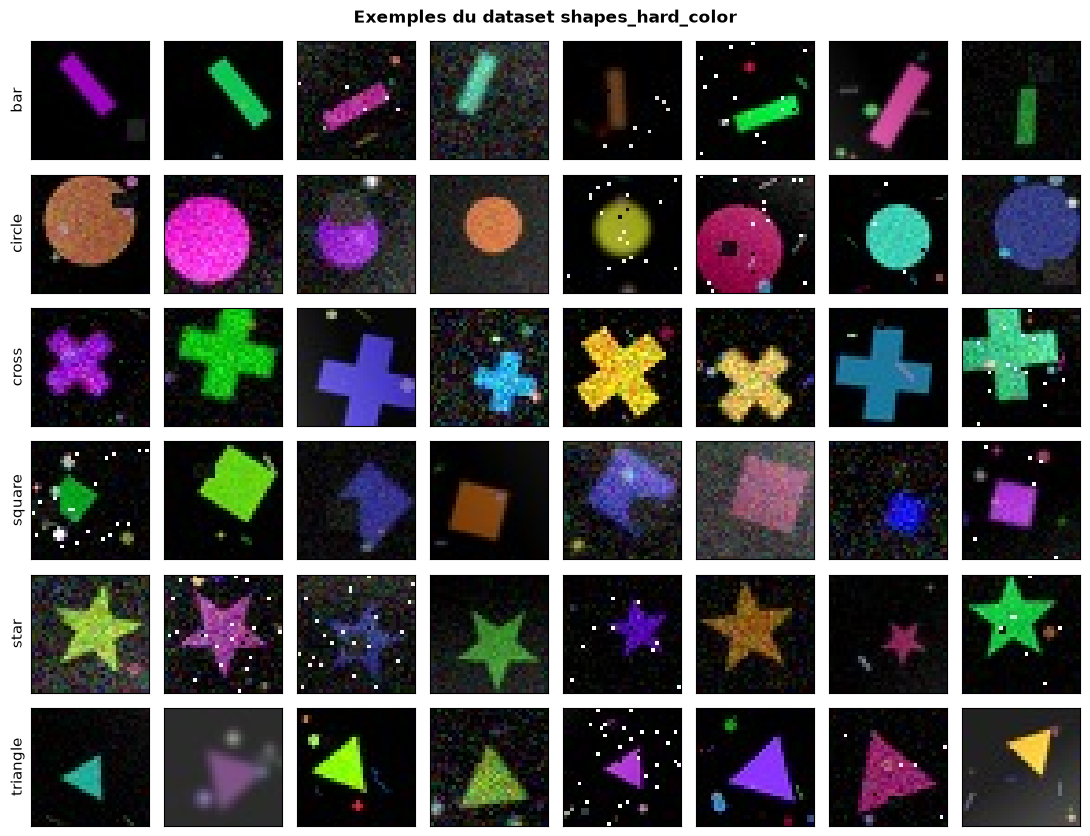

In [4]:
fig, axes = plt.subplots(6, 8, figsize=(11, 8.5))
for r in range(6):
    picks = rng.choice(np.where(y == r)[0], size=8, replace=False)
    for c in range(8):
        axes[r, c].imshow(as_image(X[picks[c]]))
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
    axes[r, 0].set_ylabel(class_names[r], fontsize=11)
fig.suptitle("Exemples du dataset shapes_hard_color", fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Entraînement de K-Means

- Modèle principal à **k = 6**, (dans l'idée : une forme par cluster).
- K-Means minimise l'inertie (somme des distances au carré des points à leur centroïde) mais peut tomber dans un minimum local selon l'initialisation.
- `n_init` lance plusieurs départs indépendants via l'amorçage k-means++ et conserve le meilleur ; réglé à 10 sur le modèle principal.
- On entraîne une fois pour toutes les valeurs de K étudiées `[3, 6, 64, 128, 256, 512]`, réutilisées partout. Grands K coûteux : `n_init` petit (1-2) et `max_iter` modéré pour tenir le runtime.

In [5]:
K_VALUES = [3, 6, 64, 128, 256, 512]
FIT_CONFIG = {3: (10, 100), 6: (10, 100), 64: (2, 60), 128: (2, 50), 256: (1, 50), 512: (1, 40)}

models = {}
for k in K_VALUES:
    n_init, max_iter = FIT_CONFIG[k]
    models[k] = KMeans(n_clusters=k, n_init=n_init, max_iter=max_iter, random_state=0).fit(X)
    m = models[k]
    print(f"k = {k:3d}  |  n_init = {n_init:2d}  |  inertie = {m.inertia_:11,.0f}  |  itérations = {m.n_iter_}")

kmeans = models[6]  # modèle principal (n_init = 10)

k =   3  |  n_init = 10  |  inertie =     924,911  |  itérations = 40
k =   6  |  n_init = 10  |  inertie =     851,051  |  itérations = 30
k =  64  |  n_init =  2  |  inertie =     625,391  |  itérations = 60
k = 128  |  n_init =  2  |  inertie =     584,699  |  itérations = 40
k = 256  |  n_init =  1  |  inertie =     545,872  |  itérations = 45
k = 512  |  n_init =  1  |  inertie =     501,963  |  itérations = 29


### Combien d'initialisations ?

- On relance k = 6 depuis dix graines, une seule initialisation chacune, et on observe la dispersion des inerties.
- Courbe "gain apporté par n_init" : inertie du meilleur des n premiers départs, en fonction de n.
- Le meilleur se stabilise vite : k-means++ place déjà des centres bien répartis, chaque départ tombe dans un bassin d'inertie voisin.

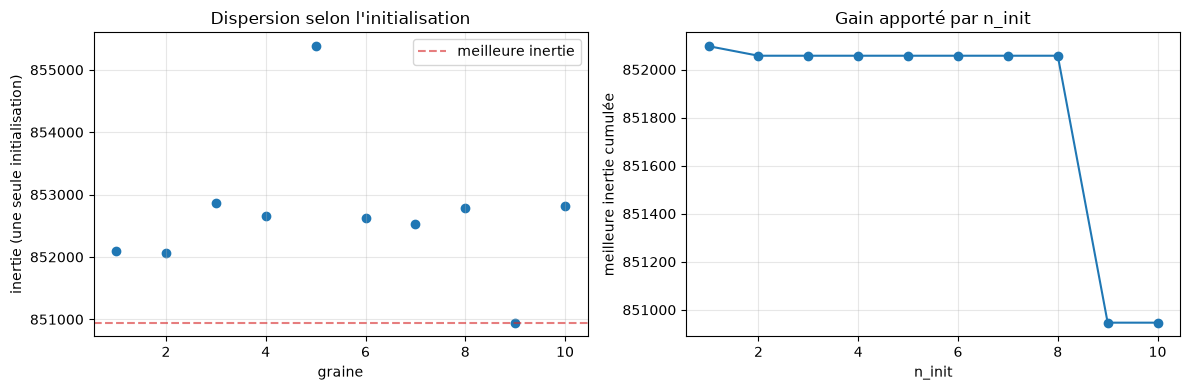

Écart pire / meilleure initialisation : 0.52%
Gain du 1er au 10e départ            : 0.14%


In [7]:
single_inertias = np.array([
    KMeans(n_clusters=6, n_init=1, max_iter=100, random_state=s).fit(X).inertia_
    for s in range(10)
])
best_so_far = np.minimum.accumulate(single_inertias)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.scatter(range(1, 11), single_inertias, color="tab:blue")
ax1.axhline(single_inertias.min(), color="tab:red", linestyle="--", alpha=0.6, label="meilleure inertie")
ax1.set_xlabel("graine")
ax1.set_ylabel("inertie (une seule initialisation)")
ax1.set_title("Dispersion selon l'initialisation")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(range(1, 11), best_so_far, "o-")
ax2.set_xlabel("n_init")
ax2.set_ylabel("meilleure inertie cumulée")
ax2.set_title("Gain apporté par n_init")
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

spread = (single_inertias.max() - single_inertias.min()) / single_inertias.min()
gain = (best_so_far[0] - best_so_far[-1]) / best_so_far[0]
print(f"Écart pire / meilleure initialisation : {spread:.2%}")
print(f"Gain du 1er au 10e départ            : {gain:.2%}")

- Écart pire / meilleure initialisation autour de 0.5%, gain du 1er au 10e départ autour de 0.1% : marginal.
- On garde `n_init = 10` sur le modèle principal, le surcoût étant négligeable.

## 3. Projection et visualisation

### 3.1 Le dictionnaire à k = 6

- Chaque centroïde se réaffiche en image 32x32 RGB : les prototypes appris.
- Une couleur dominante et une tache centrale floue, la moyenne d'un cluster effaçant la forme précise.

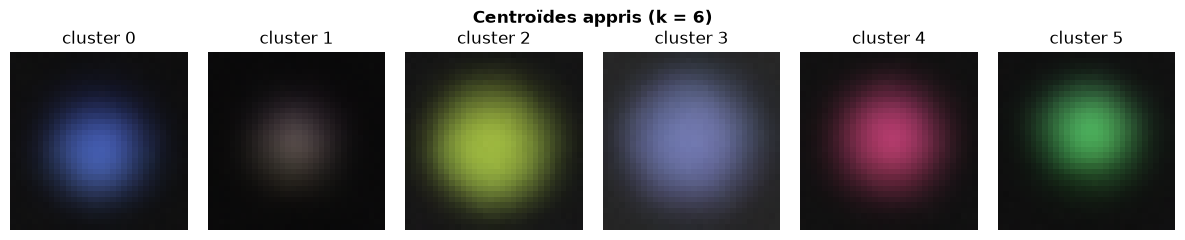

In [6]:
fig, axes = plt.subplots(1, 6, figsize=(12, 2.4))
for k, ax in enumerate(axes):
    ax.imshow(as_image(kmeans.centroids_[k]))
    ax.set_title(f"cluster {k}")
    ax.axis("off")
fig.suptitle("Centroïdes appris (k = 6)", fontweight="bold")
plt.tight_layout()
plt.show()

### 3.2 Contenu des clusters

- Lignes +/- homogènes en couleur mais mélangeant les formes : le regroupement se fait surtout par teinte dominante, pas par géométrie.

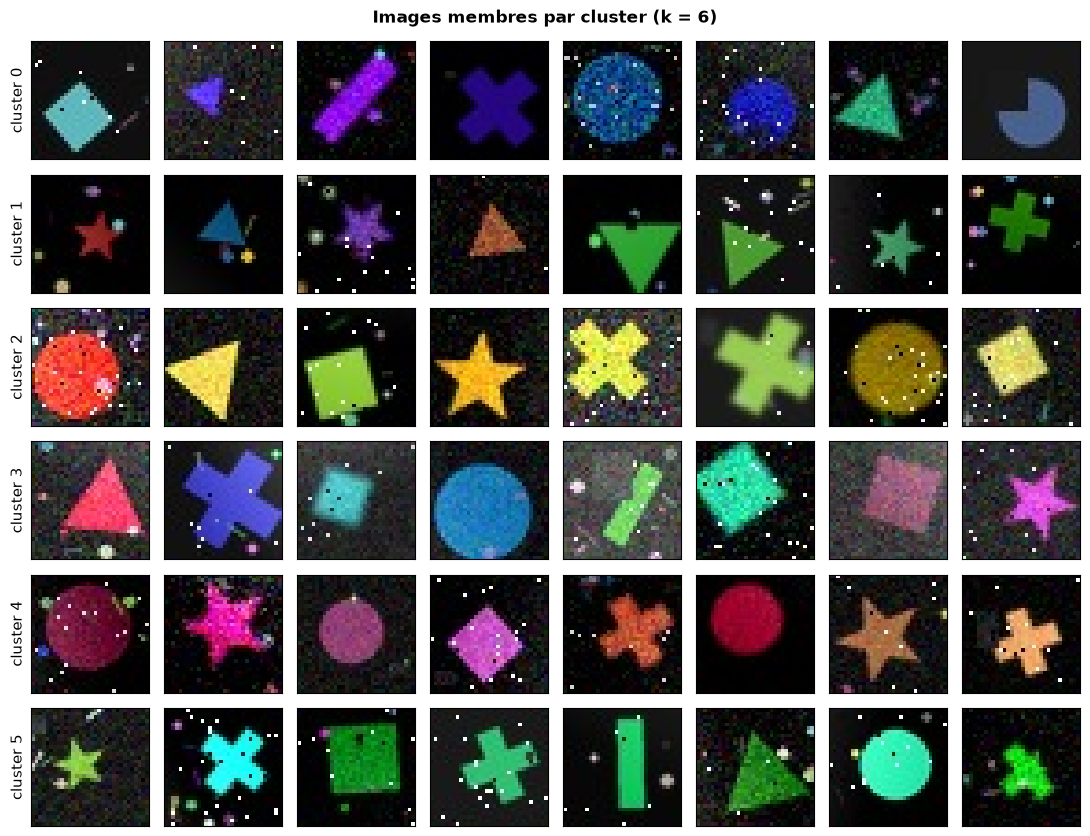

In [7]:
fig, axes = plt.subplots(6, 8, figsize=(11, 8.5))
for c in range(6):
    members = np.where(kmeans.labels_ == c)[0]
    picks = rng.choice(members, size=8, replace=False)
    for j in range(8):
        axes[c, j].imshow(as_image(X[picks[j]]))
        axes[c, j].set_xticks([]); axes[c, j].set_yticks([])
    axes[c, 0].set_ylabel(f"cluster {c}", fontsize=11)
fig.suptitle("Images membres par cluster (k = 6)", fontweight="bold")
plt.tight_layout()
plt.show()

### 3.3 Le dictionnaire à k = 64

- En montant K, le dictionnaire devient une palette de prototypes bien plus fine.
- Il couvre densément l'espace des couleurs mais reste presque partout des taches floues : K-Means dépense sa capacité à raffiner la couleur, pas la géométrie.

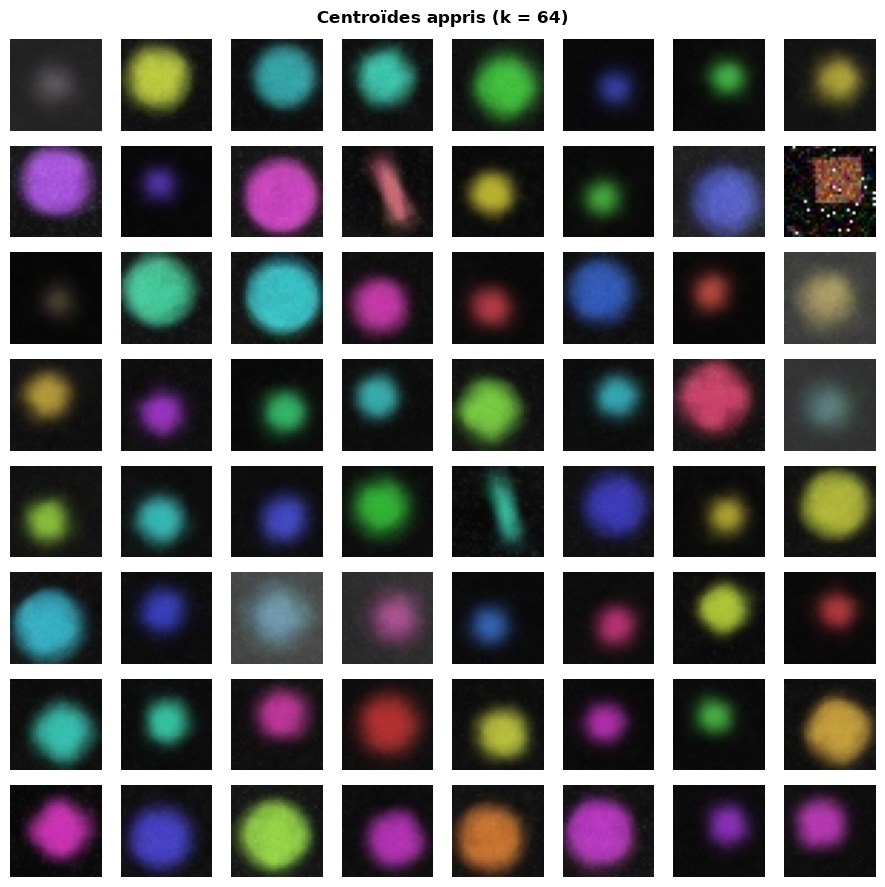

In [8]:
palette = models[64]
fig, axes = plt.subplots(8, 8, figsize=(9, 9))
for k, ax in enumerate(axes.ravel()):
    ax.imshow(as_image(palette.centroids_[k]))
    ax.axis("off")
fig.suptitle("Centroïdes appris (k = 64)", fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Compression et décompression

- On encode (chaque image devient un entier de cluster), puis on décode (chaque entier redevient son centroïde).
- `compression_report` mesure le poids du dictionnaire, celui des codes, et la MSE de reconstruction.
- À k = 6, gain énorme : un entier par image + six centroïdes partagés au lieu de 3072 flottants par image. En contrepartie, toutes les images d'un cluster se reconstruisent en une même tache, d'où une MSE élevée.

In [9]:
latent = kmeans.encode(X)
X_rec = kmeans.decode(latent)

report = compression_report(kmeans.get_codebook(), latent, X, X_rec)
for key, value in report.items():
    print(f"{key:>24} : {value}")

           latent_nature : discrete
          codebook_bytes : 73728
            latent_bytes : 10000
  total_compressed_bytes : 83728
          original_bytes : 122880000
       compression_ratio : 1467.6094018727308
      reconstruction_mse : 0.027703486382961273


### Effet de K sur le compromis débit / qualité

- Pour chaque K déjà entraîné, on mesure inertie, MSE, ratio de compression et accord avec les formes.
- Monter K enrichit le dictionnaire : la reconstruction s'améliore, le ratio chute (le dictionnaire pèse plus lourd).
- Seuil de stockage du code discret : `latent_bytes` passe de 1 à 2 octets par image dès que K dépasse 256 (uint8 -> uint16), visible à k = 512.

In [10]:
def majority_vote_accuracy(labels_pred, labels_true, n_clusters, n_classes=6):
    """Label each cluster by its majority shape, then score the induced classifier."""
    mapping = {}
    for c in range(n_clusters):
        members = labels_true[labels_pred == c]
        mapping[c] = np.bincount(members, minlength=n_classes).argmax() if members.size else -1
    mapped = np.array([mapping[c] for c in labels_pred])
    return (mapped == labels_true).mean(), mapping


sweep = []
for k in K_VALUES:
    model = models[k]
    lat = model.encode(X)
    rep = compression_report(model.get_codebook(), lat, X, model.decode(lat))
    acc, _ = majority_vote_accuracy(model.labels_, y, k)
    sweep.append((k, model.inertia_, rep["reconstruction_mse"], rep["compression_ratio"], acc))
    print(f"k = {k:3d}  ->  inertie = {model.inertia_:11,.0f}  |  MSE = {rep['reconstruction_mse']:.5f}"
          f"  |  ratio = {rep['compression_ratio']:8.1f}  |  précision forme = {acc:.2%}")

k =   3  ->  inertie =     924,911  |  MSE = 0.03011  |  ratio =   2622.1  |  précision forme = 26.10%


k =   6  ->  inertie =     851,051  |  MSE = 0.02770  |  ratio =   1467.6  |  précision forme = 26.29%
k =  64  ->  inertie =     625,391  |  MSE = 0.02036  |  ratio =    154.3  |  précision forme = 31.52%


k = 128  ->  inertie =     584,699  |  MSE = 0.01903  |  ratio =     77.6  |  précision forme = 35.56%
k = 256  ->  inertie =     545,872  |  MSE = 0.01777  |  ratio =     38.9  |  précision forme = 38.98%


k = 512  ->  inertie =     501,963  |  MSE = 0.01634  |  ratio =     19.5  |  précision forme = 43.50%


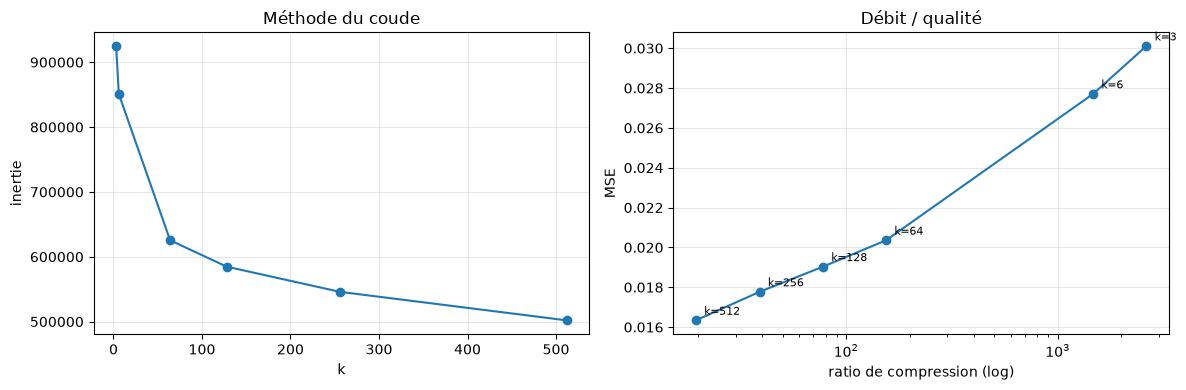

In [11]:
ks = [r[0] for r in sweep]
inertias = [r[1] for r in sweep]
mses = [r[2] for r in sweep]
ratios = [r[3] for r in sweep]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(ks, inertias, "o-")
ax1.set_xlabel("k"); ax1.set_ylabel("inertie"); ax1.set_title("Méthode du coude")
ax1.grid(alpha=0.3)

ax2.plot(ratios, mses, "o-")
for k, mse, ratio in zip(ks, mses, ratios):
    ax2.annotate(f"k={k}", (ratio, mse), textcoords="offset points", xytext=(6, 4), fontsize=8)
ax2.set_xscale("log")
ax2.set_xlabel("ratio de compression (log)"); ax2.set_ylabel("MSE"); ax2.set_title("Débit / qualité")
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Reconstruction selon K

- À petit K, chaque image se réduit à une tache colorée ; en montant K la couleur devient fidèle et quelques formes se devinent, la plupart restant des taches.

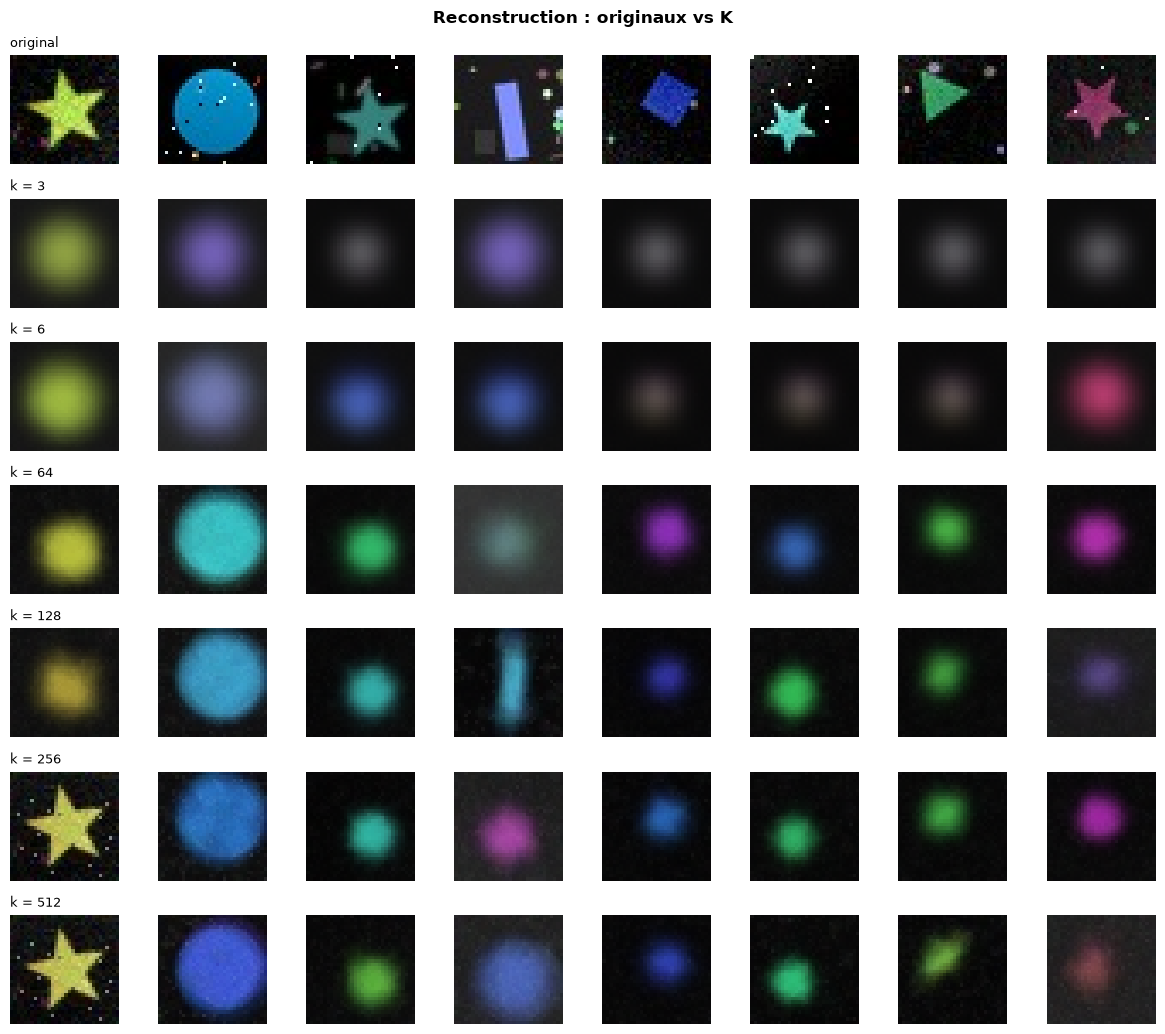

In [12]:
sample_idx = rng.choice(N, size=8, replace=False)

rows = [("original", X[sample_idx])]
for k in K_VALUES:
    model = models[k]
    rows.append((f"k = {k}", model.decode(model.encode(X[sample_idx]))))

fig, axes = plt.subplots(len(rows), 8, figsize=(12, 1.5 * len(rows)))
for r, (label, imgs) in enumerate(rows):
    for c in range(8):
        axes[r, c].imshow(as_image(imgs[c]))
        axes[r, c].axis("off")
    axes[r, 0].set_title(label, fontsize=9, loc="left")
fig.suptitle("Reconstruction : originaux vs K", fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Les clusters correspondent-ils aux formes ?

- K-Means ignore les étiquettes ; on mesure a posteriori le lien avec les formes.
- Chaque cluster reçoit sa forme majoritaire ; la précision de ce classement induit égale la pureté globale des clusters (mêmes mesures ici, une seule courbe suffit).
- Artefact central : l'évolution de cette précision selon K.

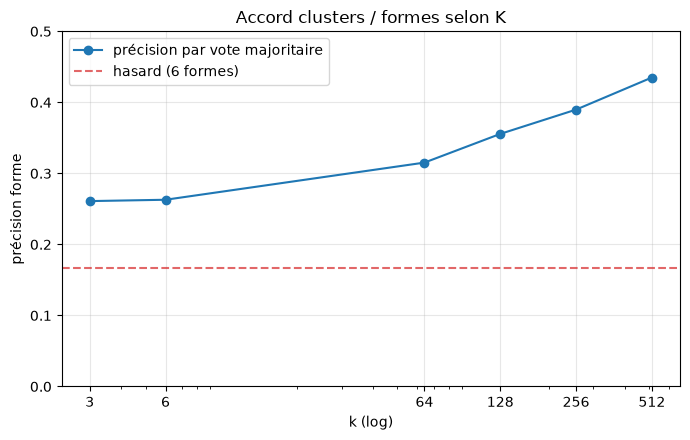

In [13]:
ks = [r[0] for r in sweep]
accs = [r[4] for r in sweep]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(ks, accs, "o-", label="précision par vote majoritaire")
ax.axhline(1 / 6, color="tab:red", linestyle="--", alpha=0.7, label="hasard (6 formes)")
ax.set_xscale("log")
ax.set_xticks(ks); ax.set_xticklabels(ks)
ax.set_xlabel("k (log)"); ax.set_ylabel("précision forme")
ax.set_ylim(0, 0.5)
ax.set_title("Accord clusters / formes selon K")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Table de contingence à k = 6

- Croise clusters et formes réelles ; pureté par cluster = fraction de la forme dominante.

In [14]:
acc, mapping = majority_vote_accuracy(kmeans.labels_, y, 6)
print(f"Précision par vote majoritaire (forme, k = 6) : {acc:.2%}")
print(f"Niveau du hasard (6 formes équilibrées)       : {1 / 6:.2%}\n")
for c in range(6):
    counts = np.bincount(y[kmeans.labels_ == c], minlength=6)
    purity = counts.max() / counts.sum()
    print(f"cluster {c}: forme dominante = {class_names[mapping[c]]:>8}  |  pureté = {purity:5.1%}  |  taille = {counts.sum()}")

Précision par vote majoritaire (forme, k = 6) : 26.29%
Niveau du hasard (6 formes équilibrées)       : 16.67%

cluster 0: forme dominante =    cross  |  pureté = 19.5%  |  taille = 1545
cluster 1: forme dominante =      bar  |  pureté = 28.2%  |  taille = 3309
cluster 2: forme dominante =   circle  |  pureté = 38.0%  |  taille = 879
cluster 3: forme dominante =   circle  |  pureté = 42.2%  |  taille = 864
cluster 4: forme dominante =   circle  |  pureté = 22.0%  |  taille = 1678
cluster 5: forme dominante =     star  |  pureté = 19.0%  |  taille = 1725


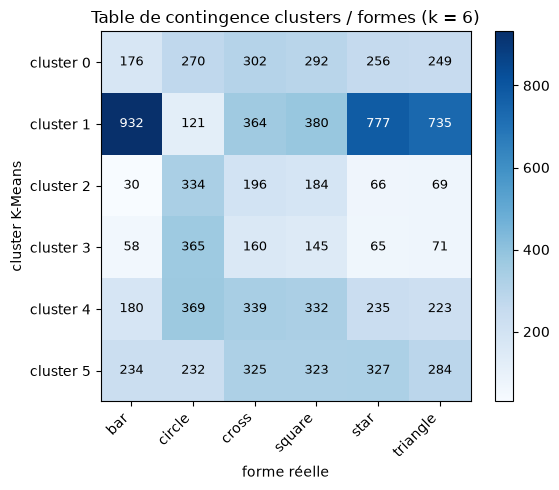

In [15]:
contingency = np.zeros((6, 6), dtype=int)
for c in range(6):
    contingency[c] = np.bincount(y[kmeans.labels_ == c], minlength=6)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(contingency, cmap="Blues")
ax.set_xticks(range(6)); ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticks(range(6)); ax.set_yticklabels([f"cluster {c}" for c in range(6)])
ax.set_xlabel("forme réelle"); ax.set_ylabel("cluster K-Means")
for c in range(6):
    for s in range(6):
        ax.text(s, c, contingency[c, s], ha="center", va="center",
                color="white" if contingency[c, s] > contingency.max() / 2 else "black", fontsize=9)
ax.set_title("Table de contingence clusters / formes (k = 6)")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

- Précision proche du hasard, progression lente avec K : les clusters supplémentaires raffinent surtout couleur et position, pas la forme.
- Sur pixels bruts RGB, la distance euclidienne est dominée par la couleur puis la pose ; séparer les formes demanderait une représentation invariante à ces deux facteurs.

## 6. Génération de données

- Vu comme modèle génératif, K-Means définit une loi a priori sur les codes : une catégorielle sur les K indices de cluster, estimée par les fréquences d'assignation.
- Générer = tirer un indice selon cette loi, puis renvoyer son centroïde (décodage déterministe).
- Support de la loi = exactement les K centroïdes : aucune image hors dictionnaire.
- On compare k = 6 et k = 64 pour voir le vocabulaire s'enrichir.

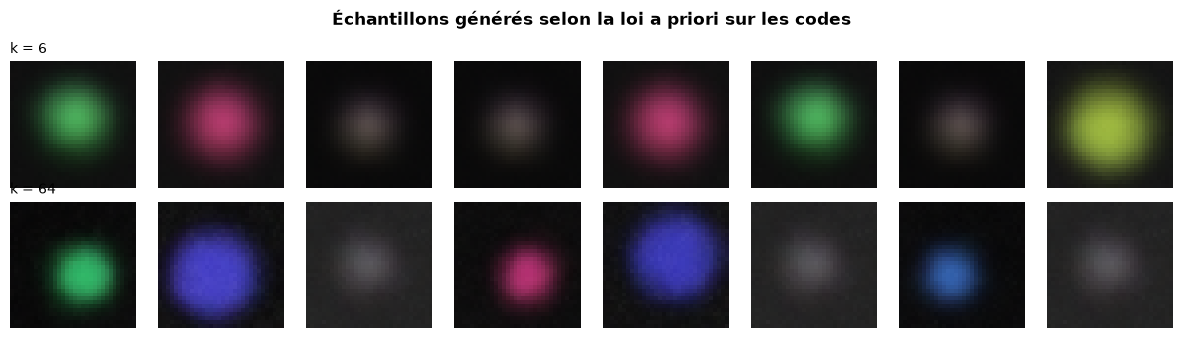

In [16]:
def sample_from(model, n_samples):
    """Draw cluster codes from the empirical assignment frequencies, decode to centroids."""
    prior = np.bincount(model.labels_, minlength=model.n_clusters) / len(model.labels_)
    codes = Latent(array=rng.choice(model.n_clusters, size=n_samples, p=prior), nature="discrete")
    return codes.array, model.decode(codes)


fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for row, model in enumerate([models[6], models[64]]):
    codes, gen = sample_from(model, 8)
    for col in range(8):
        axes[row, col].imshow(as_image(gen[col]))
        axes[row, col].axis("off")
    axes[row, 0].set_title(f"k = {model.n_clusters}", fontsize=10, loc="left")
fig.suptitle("Échantillons générés selon la loi a priori sur les codes", fontweight="bold")
plt.tight_layout()
plt.show()

- Images générables = exactement les K centroïdes : le modèle ne crée aucune forme ni couleur inédite, seulement des répétitions de ses prototypes pondérées par la loi a priori.
- Augmenter K enrichit ce vocabulaire sans jamais atteindre une vraie diversité, ce qui motive les modèles à espace latent continu.

## 7. Conclusions

- Projection / visualisation : les centroïdes sont des prototypes chromatiques ; le contenu des clusters confirme un regroupement par teinte dominante plutôt que par forme. Un dictionnaire plus grand couvre plus finement l'espace couleur.
- Compression / décompression : à k = 6, gain maximal (~1470x) mais reconstruction grossière (MSE ~0.028) ; monter K améliore la MSE (~0.016 à k = 512) et fait chuter le ratio (~20x). Le code discret passe à 2 octets par image au-delà de K = 256.
- Clusters vs formes : précision par vote majoritaire de ~26% (k = 6) à ~44% (k = 512), loin des 17% du hasard mais jamais fidèle à la forme ; la distance euclidienne sur pixels bruts est dominée par la couleur puis la pose.
- Génération : catégorielle sur K prototypes, aucune nouveauté ; faiblesse générative intrinsèque de K-Means.
- Initialisation : k-means++ suivi de plusieurs n_init stabilise l'inertie ; au-delà de quelques départs le gain est marginal (~0.1% à k = 6).